In [1]:
from pathlib import Path
import xarray as xr
SUSC_DIR = Path('/share/pech2273/susceptibility')
ACT_D = Path('/share/pech2273/')
ds_alllevels = xr.open_dataset(SUSC_DIR/'susceptibility_all_levels.nc')
ds_actD = xr.open_dataset(ACT_D/'Dact_weighted.nc')

In [2]:
ds_actD

<xarray.Dataset> Size: 6GB
Dimensions:        (lat: 96, lon: 144, lev: 10, time: 11689)
Coordinates:
  * lat            (lat) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * lon            (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * lev            (lev) float64 80B 691.4 763.4 820.9 ... 957.5 976.3 992.6
  * time           (time) datetime64[ns] 94kB 2011-01-01 ... 2015-01-01
Data variables:
    Dact_weighted  (time, lev, lat, lon) float32 6GB ...

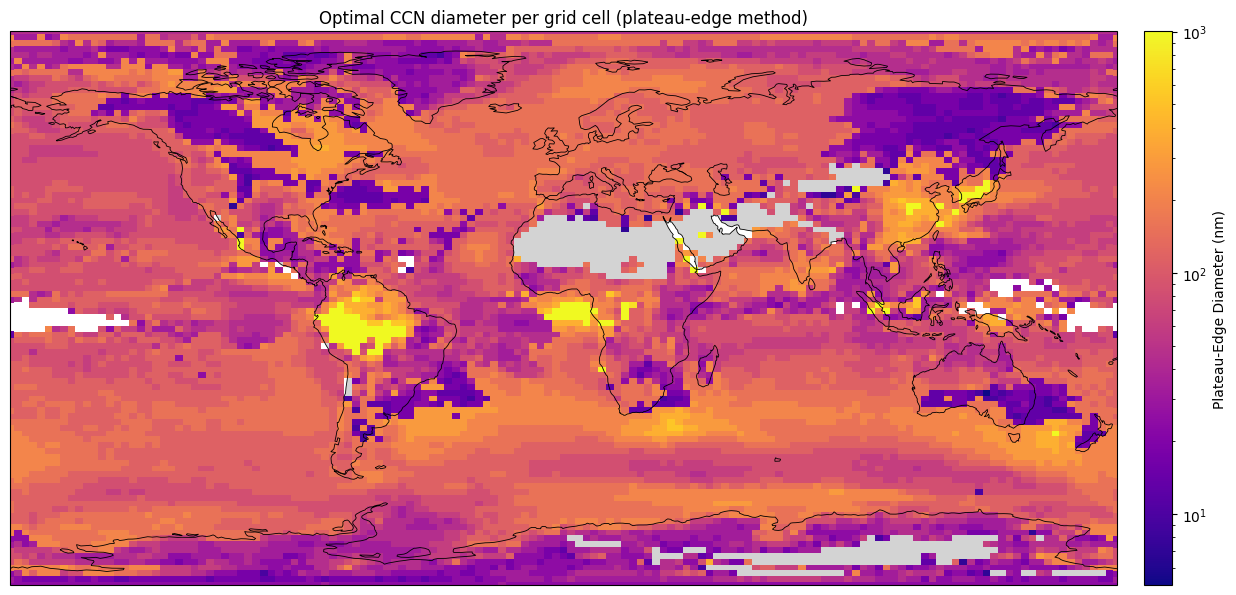

Min optimal diameter:    5.1 nm
Max optimal diameter:    1002.4 nm
Mean optimal diameter:   115.6 nm
Median optimal diameter: 113.8 nm


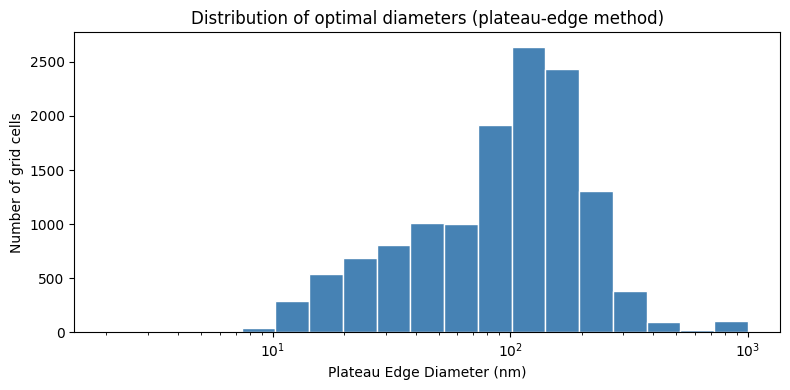

In [3]:
from scipy.ndimage import gaussian_filter1d
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib as mpl

# ── Extract data ─────────────────────────────────────────────
data = ds_alllevels.slope.sel(updraft_q='Total')  # (lat, lon, radius)

lat = data.lat.values
lon = data.lon.values
radius = data.radius.values
diameter = radius * 2  # nm

# Reshape to (n_gridpoints, n_radius) = (96*144, 21)
vals = data.values.reshape(-1, len(radius))  # (13824, 21)

# ── Handle NaNs ──────────────────────────────────────────────
nan_mask = np.any(np.isnan(vals), axis=1)  # True where any radius is NaN
valid_mask = ~nan_mask

vals_valid = vals[valid_mask]  # only non-NaN grid points

def find_plateau_edge(profile, diameter, sigma=2.0, drop_threshold=0.05):
    smooth        = gaussian_filter1d(profile, sigma=sigma)
    gradient      = np.gradient(smooth)
    profile_range = smooth.max() - smooth.min()
    if profile_range == 0:
        return np.nan
    norm_gradient   = gradient / profile_range
    decline_indices = np.where(norm_gradient < -drop_threshold)[0]
    if len(decline_indices) == 0:
        return diameter[-1]
    edge_idx = max(0, decline_indices[0] - 1)
    return diameter[edge_idx]

# ── Apply to all valid grid points ────────────────────────────
optimal_diameters_valid = np.array([
    find_plateau_edge(vals_valid[idx], diameter, sigma=1.5, drop_threshold=0.05)
    for idx in range(len(vals_valid))
])

# ── Rebuild full grid ─────────────────────────────────────────
optimal_diameters_full = np.full(len(nan_mask), np.nan)
optimal_diameters_full[valid_mask] = optimal_diameters_valid
optimal_diameters_2d = optimal_diameters_full.reshape(len(lat), len(lon))

# ── Map ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6),
                       subplot_kw={'projection': ccrs.PlateCarree()})

cmap = plt.cm.plasma.copy()
cmap.set_bad(alpha=0)

im = ax.pcolormesh(lon, lat,
                   np.ma.masked_invalid(optimal_diameters_2d),
                   cmap=cmap,
                   norm=mpl.colors.LogNorm(
                       vmin=np.nanmin(optimal_diameters_2d),
                       vmax=np.nanmax(optimal_diameters_2d)
                   ),
                   transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
cb.set_label('Plateau-Edge Diameter (nm)')
ax.set_title('Optimal CCN diameter per grid cell (plateau-edge method)')
plt.tight_layout()
plt.show()

# ── Summary statistics ────────────────────────────────────────
print(f"Min optimal diameter:    {np.nanmin(optimal_diameters_2d):.1f} nm")
print(f"Max optimal diameter:    {np.nanmax(optimal_diameters_2d):.1f} nm")
print(f"Mean optimal diameter:   {np.nanmean(optimal_diameters_2d):.1f} nm")
print(f"Median optimal diameter: {np.nanmedian(optimal_diameters_2d):.1f} nm")

# ── Distribution ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
log_bins = np.logspace(np.log10(diameter.min()), np.log10(diameter.max()), 20)
ax.hist(optimal_diameters_valid, bins=log_bins,
        color='steelblue', edgecolor='white')
ax.set_xscale('log')
ax.set_xlabel('Plateau Edge Diameter (nm)')
ax.set_ylabel('Number of grid cells')
ax.set_title('Distribution of optimal diameters (plateau-edge method)')
plt.tight_layout()
plt.show()

Per-cell percentile rank of plateau edge within Dact distribution:
  n cells = 13264
  median rank = 53.0%   mean rank = 50.6%
  fraction of cells where edge sits between 25-75th pct of Dact: 26.5%

Paired comparison across 13264 cells:

Edge vs per-cell MEAN:
  median(edge - ref) = +0.40 nm
  mean  (edge - ref) = +16.36 nm
  Wilcoxon paired: W=39155760, p=6.33e-28
  log-log Pearson r = 0.300

Edge vs per-cell MEDIAN:
  median(edge - ref) = +2.22 nm
  mean  (edge - ref) = +18.50 nm
  Wilcoxon paired: W=37762903, p=3.17e-45
  log-log Pearson r = 0.309

Edge is closer to the cell's MEDIAN than its MEAN in 57.0% of cells.


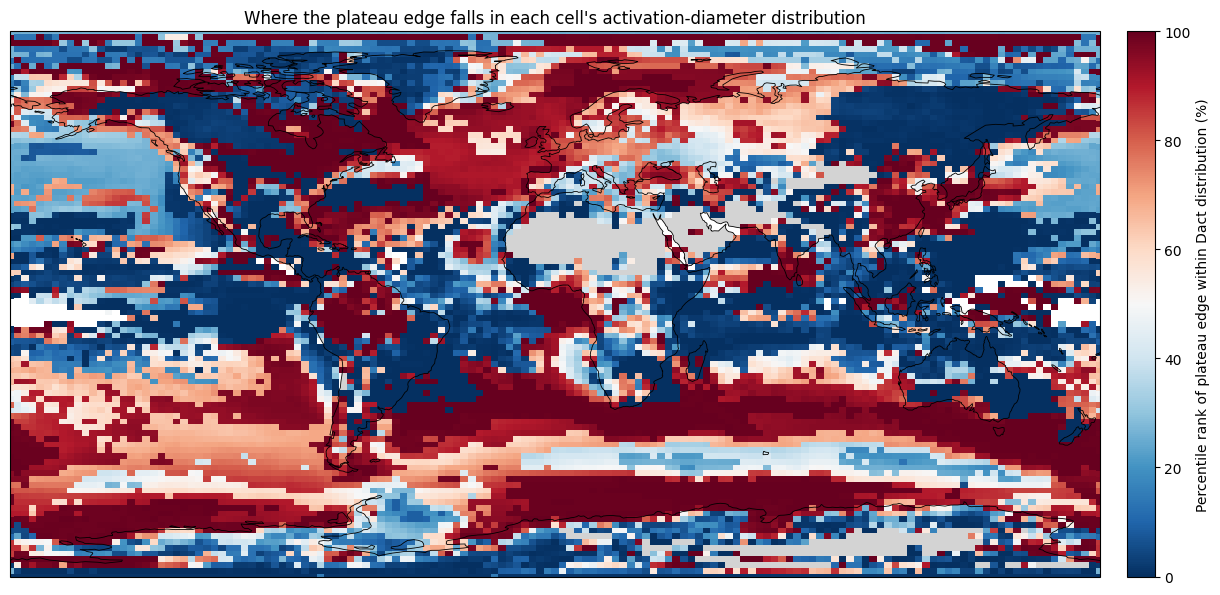

In [4]:
import numpy as np
import xarray as xr
from scipy import stats
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ── 1. load Dact distribution ─────────────────────────────────
ds_actD = xr.open_dataset(ACT_D / 'Dact_weighted.nc')
dact = ds_actD['Dact_weighted']          # (time, lev, lat, lon)
dact = dact.where(dact >= 1.0)            # drop the negligible sub-nm tail

# Pool time+lev (matches all-levels plateau edge). For a single level,
# do dact = dact.sel(lev=...) before this line.
sample_dims = [d for d in ('time', 'lev') if d in dact.dims]

dact_mean   = dact.mean(dim=sample_dims, skipna=True).transpose('lat', 'lon').values
dact_median = dact.median(dim=sample_dims, skipna=True).transpose('lat', 'lon').values

# Collapse sample dims into ONE axis -> (sample, lat, lon)
dact = dact.stack(sample=sample_dims).transpose('sample', 'lat', 'lon')

edge = optimal_diameters_2d               # (lat, lon)

# grid-alignment guard
dvals = dact.values
assert dvals.shape[1:] == edge.shape, (dvals.shape, edge.shape)
np.testing.assert_allclose(dact.lat.values, lat)
np.testing.assert_allclose(dact.lon.values, lon)

# ── 2. per-cell percentile rank of edge within Dact distribution ──
nlat, nlon = edge.shape
pct_rank = np.full((nlat, nlon), np.nan)
for i in range(nlat):
    for j in range(nlon):
        e = edge[i, j]
        col = dvals[:, i, j]
        col = col[np.isfinite(col)]
        if np.isfinite(e) and col.size > 5:
            pct_rank[i, j] = 100.0 * np.mean(col <= e)

pr = pct_rank[np.isfinite(pct_rank)]
print("Per-cell percentile rank of plateau edge within Dact distribution:")
print(f"  n cells = {pr.size}")
print(f"  median rank = {np.median(pr):.1f}%   mean rank = {pr.mean():.1f}%")
print(f"  fraction of cells where edge sits between 25-75th pct of Dact: "
      f"{np.mean((pr >= 25) & (pr <= 75)):.1%}")
# rank ~50% => edge sits near the cell's MEDIAN.

# ── 3. paired comparison: edge vs per-cell mean and per-cell median ──
m = np.isfinite(edge) & np.isfinite(dact_mean) & np.isfinite(dact_median)
e, dmu, dmd = edge[m], dact_mean[m], dact_median[m]

print(f"\nPaired comparison across {e.size} cells:")
for name, ref in [("per-cell MEAN", dmu), ("per-cell MEDIAN", dmd)]:
    d = e - ref
    print(f"\nEdge vs {name}:")
    print(f"  median(edge - ref) = {np.median(d):+.2f} nm")
    print(f"  mean  (edge - ref) = {d.mean():+.2f} nm")
    w = stats.wilcoxon(d)
    print(f"  Wilcoxon paired: W={w.statistic:.0f}, p={w.pvalue:.3g}")
    print(f"  log-log Pearson r = {np.corrcoef(np.log(e), np.log(ref))[0,1]:.3f}")

closer_to_median = np.abs(e - dmd) < np.abs(e - dmu)
print(f"\nEdge is closer to the cell's MEDIAN than its MEAN in "
      f"{np.mean(closer_to_median):.1%} of cells.")

# ── 4. map of percentile rank (50% = edge tracks the median) ──
fig, ax = plt.subplots(figsize=(14, 6),
                       subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(lon, lat, np.ma.masked_invalid(pct_rank),
                   cmap='RdBu_r', vmin=0, vmax=100,
                   transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
cb = plt.colorbar(im, ax=ax, pad=0.02)
cb.set_label('Percentile rank of plateau edge within Dact distribution (%)')
ax.set_title("Where the plateau edge falls in each cell's activation-diameter distribution")
plt.tight_layout()
plt.show()

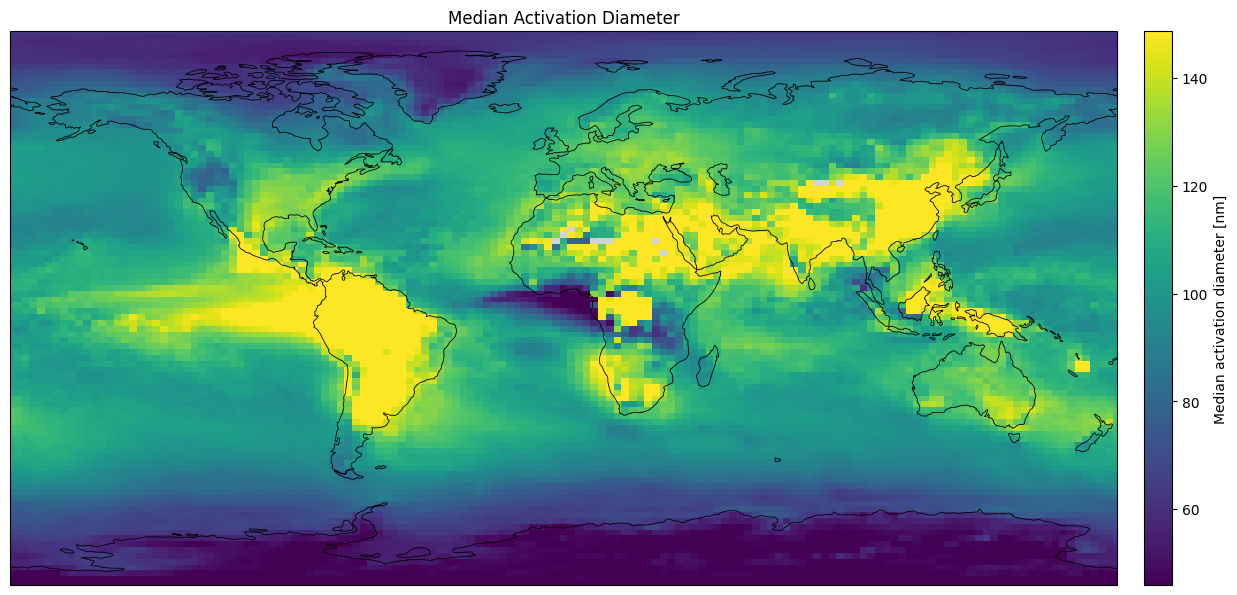

In [19]:
# ── 4. map of percentile rank (50% = edge tracks the median) ──
D_act_median = dact.median(dim='sample')
fig, ax = plt.subplots(figsize=(14, 6),
                       subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(lon, lat, np.ma.masked_invalid(D_act_median),
                   cmap='viridis', vmin=np.nanquantile(D_act_median, 0.05), vmax=np.nanquantile(D_act_median, 0.95),
                   transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
cb = plt.colorbar(im, ax=ax, pad=0.02)
cb.set_label('Median activation diameter [nm]')
ax.set_title("Median Activation Diameter")
plt.tight_layout()
plt.show()

/home/pech2273/.local/lib/python3.12/site-packages/numpy/_core/function_base.py:301: RuntimeWarning: overflow encountered in power
  return _nx.power(base, y)
/home/pech2273/.local/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1496: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
/home/pech2273/.local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7160: RuntimeWarning: invalid value encountered in multiply
  boffset = -0.5 * dr * totwidth * (1 - 1 / nx)


(array([13813.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.]),
 array([1.00000000e+001, 3.79269019e+053, 1.43844989e+106, 5.45559478e+158,
        2.06913808e+211, 7.84759970e+263,             inf,             inf,
                    inf,             inf,             inf,             inf,
                    inf,             inf,             inf,             inf,
                    inf,             inf,             inf,             inf]),
 <BarContainer object of 19 artists>)

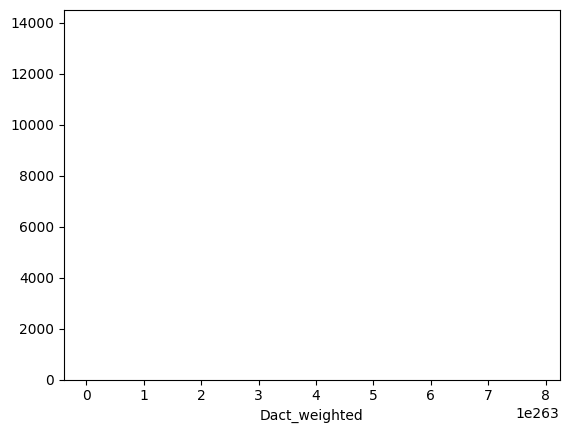

In [22]:
D_act_median.plot.hist()

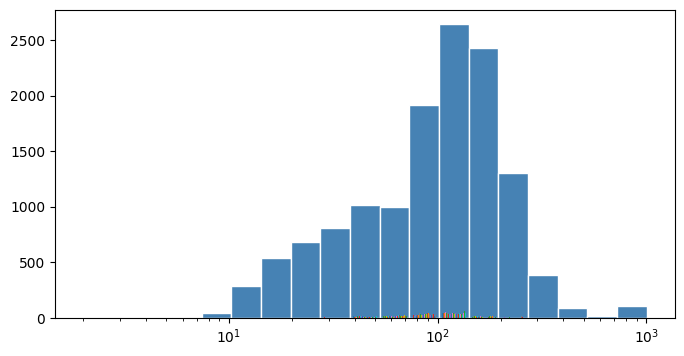

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))
log_bins = np.logspace(np.log10(diameter.min()), np.log10(diameter.max()), 20)

ax.hist(optimal_diameters_valid, bins=log_bins,
        color='steelblue', edgecolor='white')
ax.hist(D_act_median, bins = log_bins)
ax.set_xscale('log')

In [31]:
plt.hist(D_act_median.flatten)

AttributeError: 'DataArray' object has no attribute 'flatten'

In [28]:
D_act_median

<xarray.DataArray 'Dact_weighted' (lat: 96, lon: 144)> Size: 55kB
array([[40.736855, 40.685436, 40.72838 , ..., 40.738483, 40.688652,
        40.73786 ],
       [45.957714, 45.779057, 47.276016, ..., 42.685764, 43.351124,
        44.452923],
       [45.6023  , 44.28074 , 44.187363, ..., 46.78384 , 45.15153 ,
        44.669216],
       ...,
       [63.69326 , 63.737568, 64.50403 , ..., 62.419758, 62.786682,
        63.130554],
       [63.696106, 63.80237 , 63.609253, ..., 63.20948 , 62.932716,
        63.217575],
       [62.744633, 63.039303, 62.820686, ..., 62.785408, 62.97554 ,
        62.9061  ]], shape=(96, 144), dtype=float32)
Coordinates:
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5